# ABM Calibration Analysis
Empirical data · Simulated output · Regime comparison (Calm vs Stressed)

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson
import warnings; warnings.filterwarnings('ignore')

# --- Load empirical outputs from calibration ---
calm_emp     = pd.read_csv('output/fundamental_value_calm.csv')
stressed_emp = pd.read_csv('output/fundamental_value_stressed.csv')
params       = pd.read_csv('output/calibrated_params.csv')

# --- Load simulation outputs ---
calm_sim_med     = pd.read_csv('output/sim_calm_median.csv')
stressed_sim_med = pd.read_csv('output/sim_stressed_median.csv')
calm_sim_all     = pd.read_csv('output/sim_calm_runs.csv')
stressed_sim_all = pd.read_csv('output/sim_stressed_runs.csv')

print('Empirical obs: calm=%d  stressed=%d' % (len(calm_emp), len(stressed_emp)))
print('Sim runs: calm=%d  stressed=%d' % (calm_sim_all.run_id.nunique(), stressed_sim_all.run_id.nunique()))
print()
print(params[['regime','gamma','beta','alpha','sigma_v','sigma_n','g','log_lik']].to_string(index=False))


Empirical obs: calm=503  stressed=252
Sim runs: calm=50  stressed=50

  regime    gamma     beta    alpha  sigma_v  sigma_n        g     log_lik
stressed 0.100039 0.445382 0.166667 0.001776 0.006928 0.000522  885.721542
    calm 0.091175 0.271043 0.166667 0.001990 0.006857 0.000647 1779.758919


## 1 · Empirical: Price vs Fundamental Value (KF-smoothed)

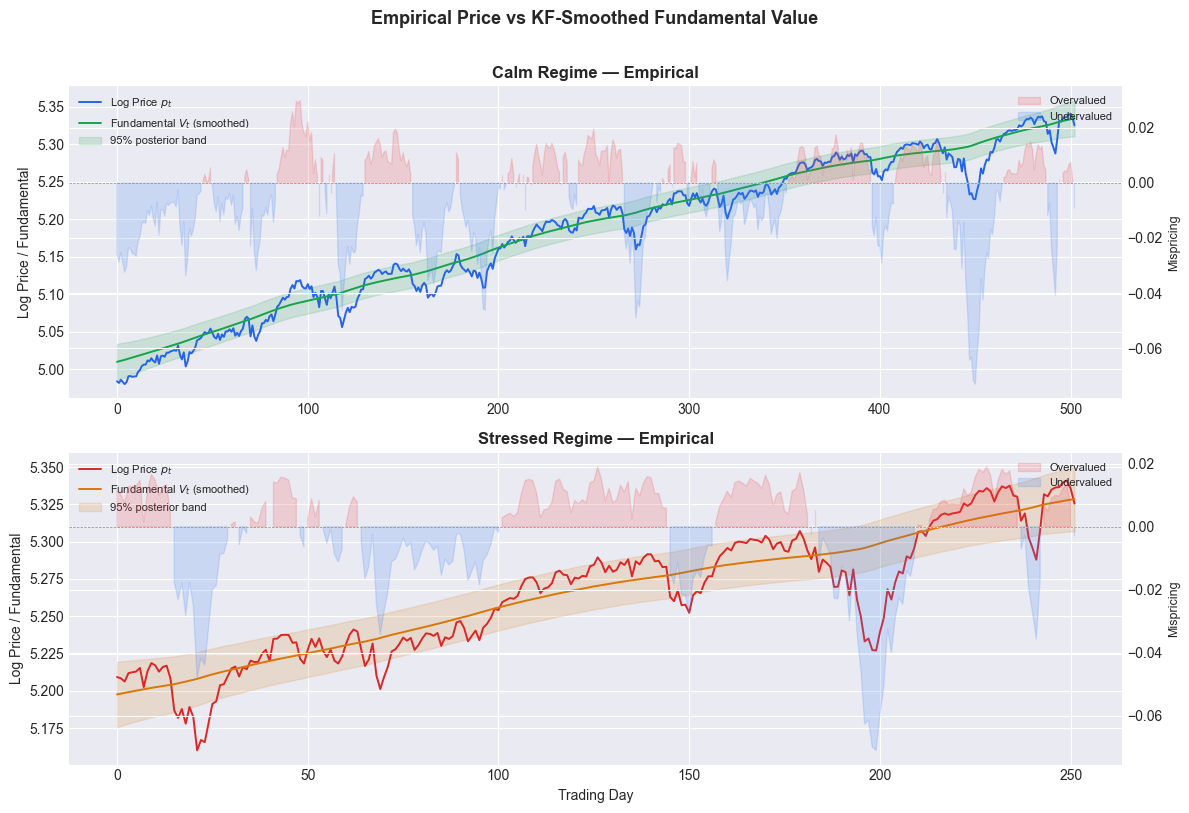

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

for ax, df, regime, cp, cv in [
    (axes[0], calm_emp,     'Calm',     '#2563eb', '#16a34a'),
    (axes[1], stressed_emp, 'Stressed', '#dc2626', '#d97706'),
]:
    t = df['t']
    ax.plot(t, df['log_price'],  color=cp, lw=1.4, label='Log Price $p_t$', zorder=3)
    ax.plot(t, df['v_smoothed'], color=cv, lw=1.4, label='Fundamental $V_t$ (smoothed)', zorder=3)
    ax.fill_between(t, df['v_smoothed'] - 1.96*df['v_stderr'],
                       df['v_smoothed'] + 1.96*df['v_stderr'],
                   color=cv, alpha=0.15, label='95% posterior band')
    mis = df['log_price'] - df['v_smoothed']
    ax2 = ax.twinx()
    ax2.fill_between(t, mis, 0, where=(mis>0), color='#ef4444', alpha=0.18, label='Overvalued')
    ax2.fill_between(t, mis, 0, where=(mis<0), color='#3b82f6', alpha=0.18, label='Undervalued')
    ax2.axhline(0, color='grey', lw=0.5, ls='--')
    ax2.set_ylabel('Mispricing', fontsize=9)
    ax.set_title(f'{regime} Regime — Empirical', fontweight='bold')
    ax.set_ylabel('Log Price / Fundamental')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

axes[1].set_xlabel('Trading Day')
plt.suptitle('Empirical Price vs KF-Smoothed Fundamental Value', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/price_vs_fundamental.png', dpi=150, bbox_inches='tight')
plt.show()


## 2 · Simulated Price vs Fundamental (Median + IQR across 50 runs)

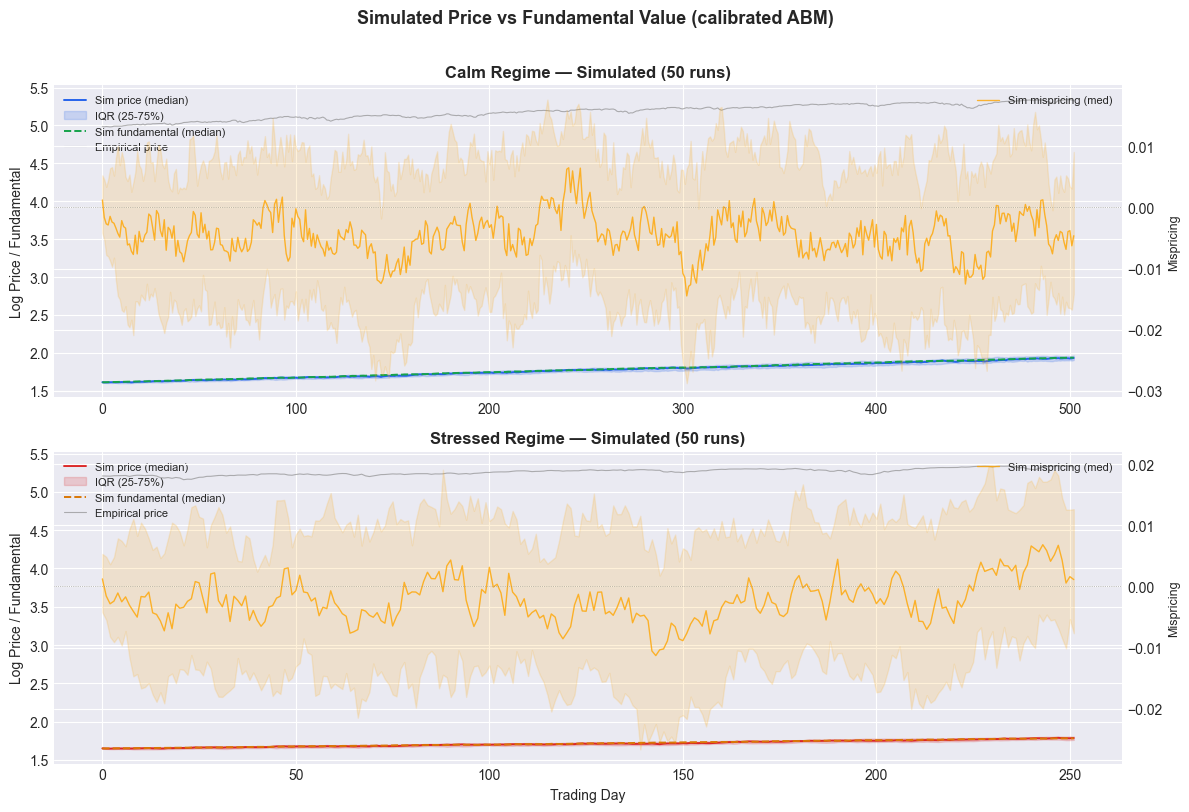

In [72]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

for ax, med, emp, regime, cp, cv in [
    (axes[0], calm_sim_med,     calm_emp,     'Calm',     '#2563eb', '#16a34a'),
    (axes[1], stressed_sim_med, stressed_emp, 'Stressed', '#dc2626', '#d97706'),
]:
    t = med['t']
    ax.plot(t, med['log_price_med'], color=cp, lw=1.4, label='Sim price (median)')
    ax.fill_between(t, med['log_price_p25'], med['log_price_p75'],
                   color=cp, alpha=0.18, label='IQR (25-75%)')
    ax.plot(t, med['log_fund_med'],  color=cv, lw=1.4, ls='--', label='Sim fundamental (median)')
    # overlay empirical as thin grey line for reference
    t_emp = np.linspace(t.min(), t.max(), len(emp))
    ax.plot(t_emp, emp['log_price'], color='grey', lw=0.8, alpha=0.6, label='Empirical price')
    ax2 = ax.twinx()
    ax2.plot(t, med['mispricing_med'], color='orange', lw=1.0, alpha=0.8, label='Sim mispricing (med)')
    ax2.fill_between(t, med['mispricing_p25'], med['mispricing_p75'],
                    color='orange', alpha=0.15)
    ax2.axhline(0, color='grey', lw=0.5, ls=':')
    ax2.set_ylabel('Mispricing', fontsize=9)
    ax.set_title(f'{regime} Regime — Simulated (50 runs)', fontweight='bold')
    ax.set_ylabel('Log Price / Fundamental')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

axes[1].set_xlabel('Trading Day')
plt.suptitle('Simulated Price vs Fundamental Value (calibrated ABM)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/sim_price_vs_fundamental.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 · Return Distribution: Empirical vs Simulated

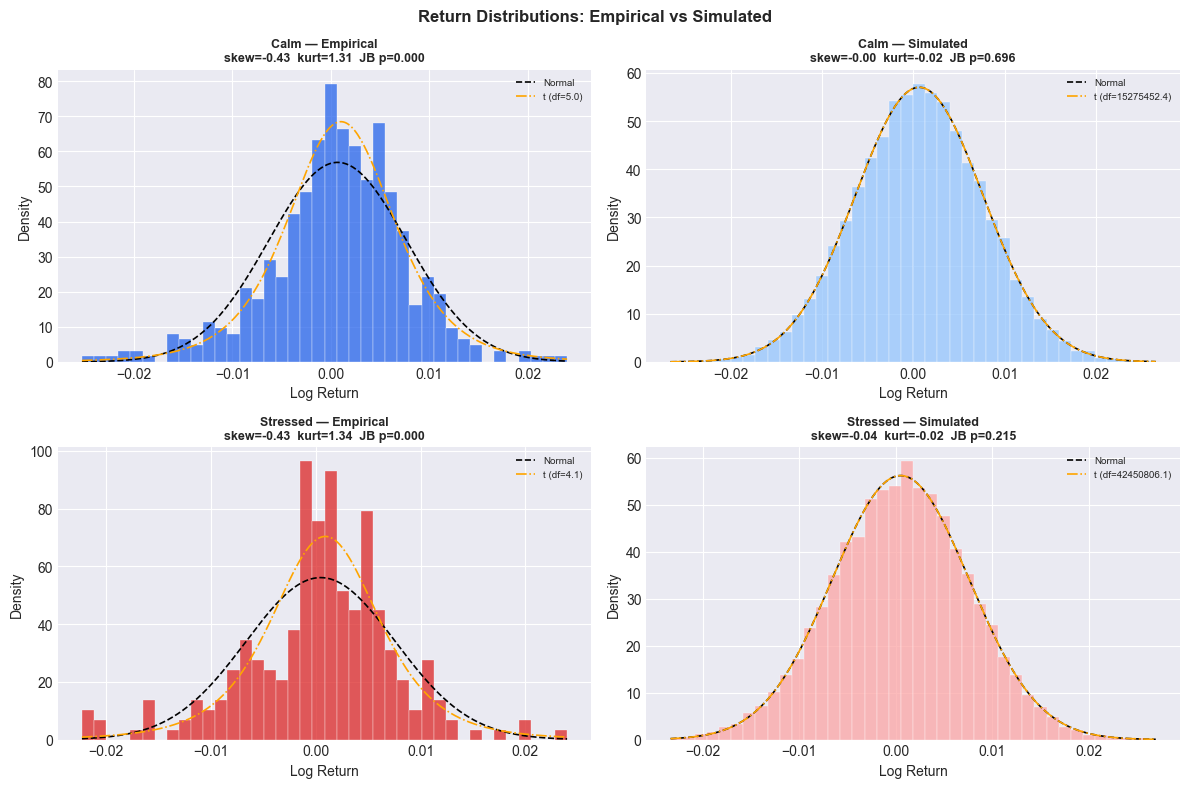

In [73]:
calm_ret_emp     = np.diff(calm_emp['log_price'].values)
stressed_ret_emp = np.diff(stressed_emp['log_price'].values)
calm_ret_sim     = calm_sim_all['log_return'].dropna().values
stressed_ret_sim = stressed_sim_all['log_return'].dropna().values

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

combos = [
    (axes[0,0], calm_ret_emp,     'Calm — Empirical',  '#2563eb'),
    (axes[0,1], calm_ret_sim,     'Calm — Simulated',  '#93c5fd'),
    (axes[1,0], stressed_ret_emp, 'Stressed — Empirical', '#dc2626'),
    (axes[1,1], stressed_ret_sim, 'Stressed — Simulated', '#fca5a5'),
]

for ax, ret, title, color in combos:
    ax.hist(ret, bins=40, color=color, alpha=0.75, density=True, edgecolor='white', lw=0.3)
    xr = np.linspace(ret.min(), ret.max(), 300)
    ax.plot(xr, stats.norm.pdf(xr, ret.mean(), ret.std()), 'k--', lw=1.2, label='Normal')
    df_t, loc_t, sc_t = stats.t.fit(ret)
    ax.plot(xr, stats.t.pdf(xr, df_t, loc_t, sc_t),
            color='orange', lw=1.2, ls='-.', label=f't (df={df_t:.1f})')
    sk, ku = stats.skew(ret), stats.kurtosis(ret)
    _, jb_p = stats.jarque_bera(ret)
    ax.set_title(f'{title}\nskew={sk:.2f}  kurt={ku:.2f}  JB p={jb_p:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Log Return'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle('Return Distributions: Empirical vs Simulated', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output/return_dist_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 · Autocorrelation: Empirical vs Simulated

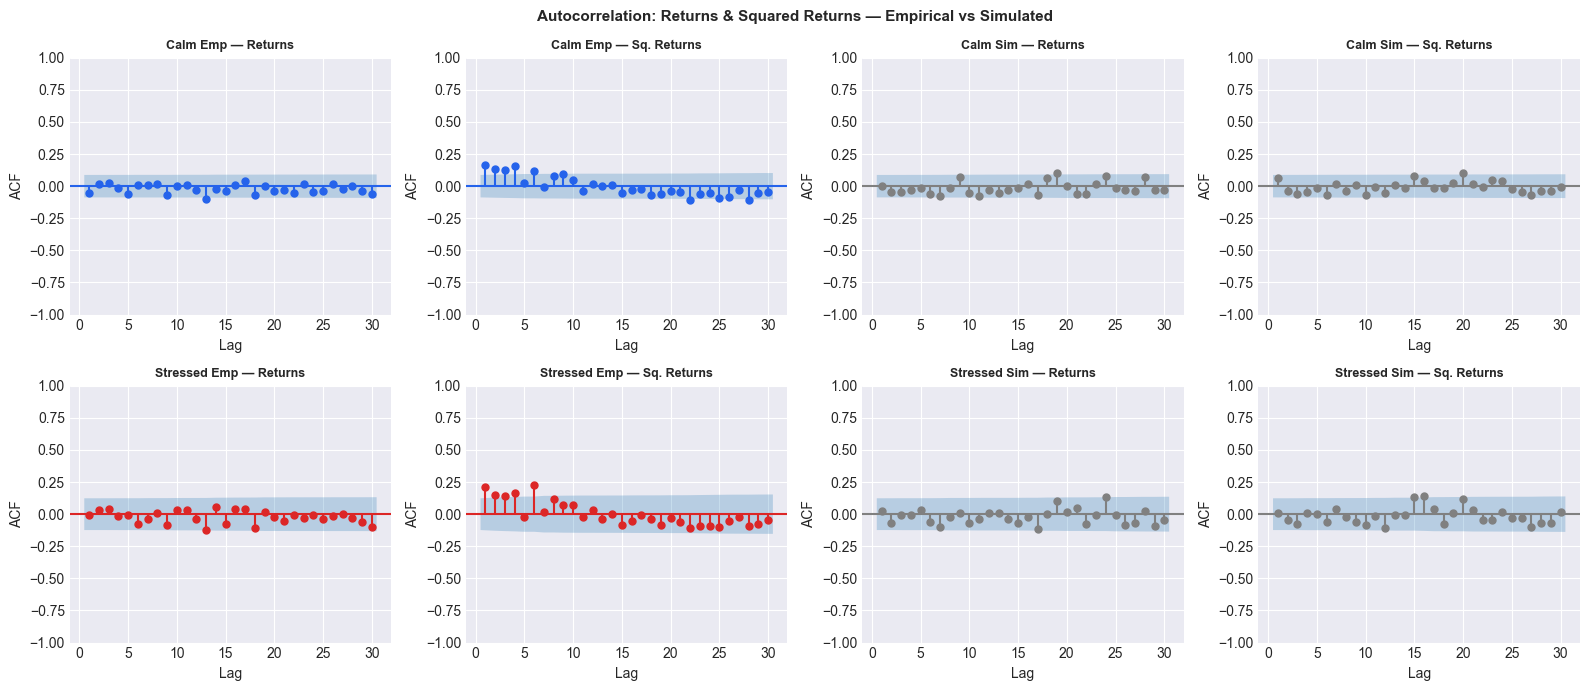

In [74]:
# Use one representative sim run (run_id=0) for ACF plots
calm_sim_r0     = calm_sim_all[calm_sim_all.run_id == 0]['log_return'].dropna().values
stressed_sim_r0 = stressed_sim_all[stressed_sim_all.run_id == 0]['log_return'].dropna().values

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

rows = [
    (calm_ret_emp,      calm_sim_r0,      'Calm'),
    (stressed_ret_emp,  stressed_sim_r0,  'Stressed'),
]
colors = ['#2563eb', '#dc2626']

for i, (emp_r, sim_r, regime) in enumerate(rows):
    c = colors[i]
    plot_acf(emp_r,   ax=axes[i,0], lags=30, color=c, alpha=0.05, zero=False,
             vlines_kwargs={'colors': c})
    axes[i,0].set_title(f'{regime} Emp — Returns', fontsize=9, fontweight='bold')

    plot_acf(emp_r**2, ax=axes[i,1], lags=30, color=c, alpha=0.05, zero=False,
             vlines_kwargs={'colors': c})
    axes[i,1].set_title(f'{regime} Emp — Sq. Returns', fontsize=9, fontweight='bold')

    plot_acf(sim_r,   ax=axes[i,2], lags=30, color='grey', alpha=0.05, zero=False,
             vlines_kwargs={'colors': 'grey'})
    axes[i,2].set_title(f'{regime} Sim — Returns', fontsize=9, fontweight='bold')

    plot_acf(sim_r**2, ax=axes[i,3], lags=30, color='grey', alpha=0.05, zero=False,
             vlines_kwargs={'colors': 'grey'})
    axes[i,3].set_title(f'{regime} Sim — Sq. Returns', fontsize=9, fontweight='bold')

    for ax in axes[i]: ax.set_xlabel('Lag'); ax.set_ylabel('ACF')

plt.suptitle('Autocorrelation: Returns & Squared Returns — Empirical vs Simulated',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('output/acf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 · Mispricing Distribution: Empirical vs Simulated

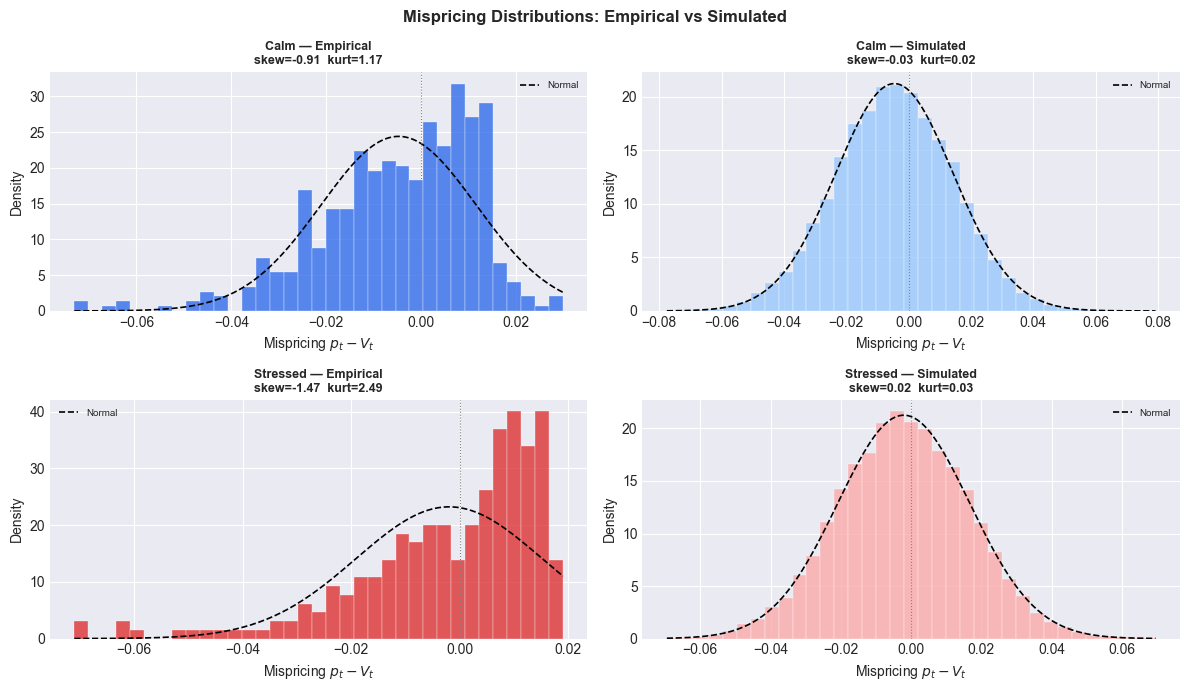

In [75]:
calm_mis_emp     = calm_emp['log_price']     - calm_emp['v_smoothed']
stressed_mis_emp = stressed_emp['log_price'] - stressed_emp['v_smoothed']
calm_mis_sim     = calm_sim_all['mispricing'].dropna()
stressed_mis_sim = stressed_sim_all['mispricing'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

combos = [
    (axes[0,0], calm_mis_emp,     'Calm — Empirical',     '#2563eb'),
    (axes[0,1], calm_mis_sim,     'Calm — Simulated',     '#93c5fd'),
    (axes[1,0], stressed_mis_emp, 'Stressed — Empirical', '#dc2626'),
    (axes[1,1], stressed_mis_sim, 'Stressed — Simulated', '#fca5a5'),
]

for ax, mis, title, color in combos:
    ax.hist(mis, bins=35, color=color, alpha=0.75, density=True, edgecolor='white', lw=0.3)
    xr = np.linspace(mis.min(), mis.max(), 200)
    ax.plot(xr, stats.norm.pdf(xr, mis.mean(), mis.std()), 'k--', lw=1.2, label='Normal')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    sk = stats.skew(mis); ku = stats.kurtosis(mis)
    ax.set_title(f'{title}\nskew={sk:.2f}  kurt={ku:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Mispricing $p_t - V_t$'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle('Mispricing Distributions: Empirical vs Simulated', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output/mispricing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Stylised Facts Distance (Gao metric)

                        vol     skew     kurt     acf1  acf2_sq
label                                                          
Calm Empirical      0.00702 -0.43091  1.31169 -0.05085  0.16666
Calm Simulated      0.00700 -0.00439 -0.02484  0.00868 -0.00233
Stressed Empirical  0.00711 -0.43311  1.33645 -0.00733  0.21246
Stressed Simulated  0.00710 -0.03738 -0.01726  0.02943 -0.00740


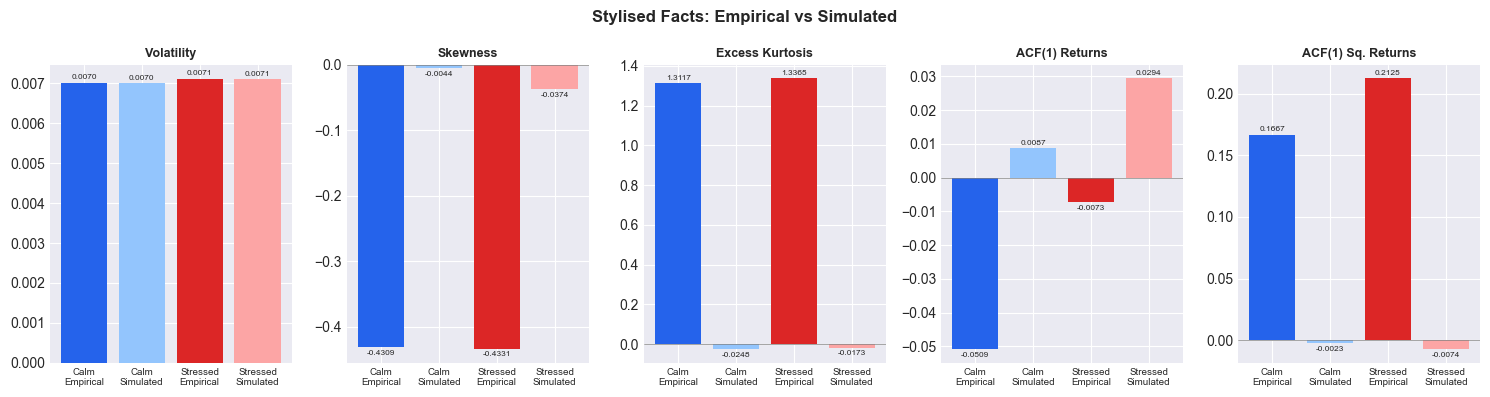

In [76]:
from scipy.stats import kurtosis, skew

def stylised_facts(returns, label):
    r = np.asarray(returns)
    r = r[~np.isnan(r)]
    return {
        'label'   : label,
        'vol'     : r.std(),
        'skew'    : skew(r),
        'kurt'    : kurtosis(r),            # excess kurtosis
        'acf1'    : pd.Series(r).autocorr(1),
        'acf2_sq' : pd.Series(r**2).autocorr(1),  # volatility clustering
    }

rows = [
    stylised_facts(calm_ret_emp,     'Calm Empirical'),
    stylised_facts(calm_ret_sim,     'Calm Simulated'),
    stylised_facts(stressed_ret_emp, 'Stressed Empirical'),
    stylised_facts(stressed_ret_sim, 'Stressed Simulated'),
]
sf = pd.DataFrame(rows).set_index('label')
print(sf.round(5).to_string())
sf.to_csv('output/stylised_facts.csv')

# Bar chart
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
metrics = ['vol', 'skew', 'kurt', 'acf1', 'acf2_sq']
titles  = ['Volatility', 'Skewness', 'Excess Kurtosis', 'ACF(1) Returns', 'ACF(1) Sq. Returns']
colors_map = {
    'Calm Empirical'    : '#2563eb',
    'Calm Simulated'    : '#93c5fd',
    'Stressed Empirical': '#dc2626',
    'Stressed Simulated': '#fca5a5',
}

for ax, m, ttl in zip(axes, metrics, titles):
    vals = sf[m]
    bars = ax.bar(range(len(vals)), vals, color=[colors_map[l] for l in vals.index])
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([l.replace(' ', '\n') for l in vals.index], fontsize=7)
    ax.set_title(ttl, fontsize=9, fontweight='bold')
    ax.axhline(0, color='grey', lw=0.5)
    ax.bar_label(bars, fmt='%.4f', fontsize=6, padding=2)

plt.suptitle('Stylised Facts: Empirical vs Simulated', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('output/stylised_facts.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · Calibrated Parameter Comparison

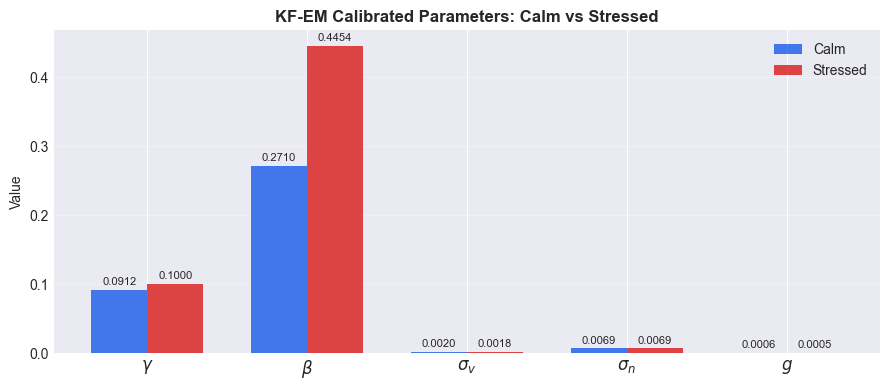


Parameter delta (stressed - calm):
  $\gamma$      calm=0.09117  stressed=0.10004  delta=+0.00886  (+9.7%)
  $\beta$       calm=0.27104  stressed=0.44538  delta=+0.17434  (+64.3%)
  $\sigma_v$    calm=0.00199  stressed=0.00178  delta=-0.00021  (-10.7%)
  $\sigma_n$    calm=0.00686  stressed=0.00693  delta=+0.00007  (+1.0%)
  $g$           calm=0.00065  stressed=0.00052  delta=-0.00012  (-19.3%)


In [77]:
p_c = params[params.regime=='calm'].iloc[0]
p_s = params[params.regime=='stressed'].iloc[0]

labels = [r'$\gamma$', r'$\beta$', r'$\sigma_v$', r'$\sigma_n$', r'$g$']
cv = [p_c.gamma, p_c.beta, p_c.sigma_v, p_c.sigma_n, p_c.g]
sv = [p_s.gamma, p_s.beta, p_s.sigma_v, p_s.sigma_n, p_s.g]

x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x-w/2, cv, w, label='Calm',     color='#2563eb', alpha=0.85)
b2 = ax.bar(x+w/2, sv, w, label='Stressed', color='#dc2626', alpha=0.85)
ax.bar_label(b1, fmt='%.4f', fontsize=8, padding=2)
ax.bar_label(b2, fmt='%.4f', fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Value'); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('KF-EM Calibrated Parameters: Calm vs Stressed', fontweight='bold')
plt.tight_layout()
plt.savefig('output/parameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nParameter delta (stressed - calm):')
for lbl, c, s in zip(labels, cv, sv):
    print(f'  {lbl:12s}  calm={c:.5f}  stressed={s:.5f}  delta={s-c:+.5f}  ({100*(s-c)/(abs(c)+1e-12):+.1f}%)')


## 8 · Summary Statistics

In [78]:
rows = []
for ret, mis, label in [
    (calm_ret_emp,     calm_mis_emp,     'Calm Empirical'),
    (calm_ret_sim,     calm_mis_sim,     'Calm Simulated'),
    (stressed_ret_emp, stressed_mis_emp, 'Stressed Empirical'),
    (stressed_ret_sim, stressed_mis_sim, 'Stressed Simulated'),
]:
    r = np.asarray(ret); m = np.asarray(mis)
    r = r[~np.isnan(r)]; m = m[~np.isnan(m)]
    rows.append({
        'Series'         : label,
        'N'              : len(r),
        'Mean ret'       : f'{r.mean():.5f}',
        'Std ret'        : f'{r.std():.5f}',
        'Skewness'       : f'{stats.skew(r):.3f}',
        'Exc. kurtosis'  : f'{stats.kurtosis(r):.3f}',
        'JB p-val'       : f'{stats.jarque_bera(r)[1]:.4f}',
        'Mean |mispric|' : f'{np.abs(m).mean():.5f}',
        'Std mispric'    : f'{m.std():.5f}',
        'DW stat'        : f'{durbin_watson(r):.3f}',
    })

summary = pd.DataFrame(rows).set_index('Series')
display(summary.T)
summary.to_csv('output/summary_statistics.csv')
print('Saved to output/summary_statistics.csv')


Series,Calm Empirical,Calm Simulated,Stressed Empirical,Stressed Simulated
N,502,25100,251,12550
Mean ret,0.00068,0.00064,0.00046,0.00052
Std ret,0.00702,0.00700,0.00711,0.00710
Skewness,-0.431,-0.004,-0.433,-0.037
Exc. kurtosis,1.312,-0.025,1.336,-0.017
JB p-val,0.0000,0.6956,0.0000,0.2145
Mean |mispric|,0.01308,0.01543,0.01300,0.01508
Std mispric,0.01634,0.01880,0.01714,0.01876
DW stat,2.077,1.966,1.997,1.931


Saved to output/summary_statistics.csv
